# Интеллектуальный анализ данных – весна 2025

# Домашнее задание 7: Деревья. Случайный лес

Правила:

- Домашнее задание оценивается в 10 баллов.


- Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.


- Можно использовать любые свободные источники с обязательным указанием ссылки на них.


- Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

<!-- ![](https://github.com/hse-ds/iad-intro-ds/blob/master/2025/homeworks/hw07_trees/meme.jpg?raw=1) -->
<img src="https://github.com/hse-ds/iad-intro-ds/blob/master/2025/homeworks/hw07_trees/meme.jpg?raw=1" alt="Drawing" style="width: 700px;"/>

## Часть 1: Основы построения решающие дерева (1.5 балла)

В этой части все расчёты необходимо реализовывать в виде запрограммированных формул, например, на `numpy`. **Нельзя использовать готовые реализации**. Например, если в задании требуется рассчитать энтропию, то требуется в каком-то виде релизовать расчёт по формуле, но нельзя использовать готовую реализацию `some_module.entropy()`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Задание 1.1 (0.5 балла)** Пусть известно, что в вершину решающего дерева попали 10 объектов, 8 из которых имеют метку класса $k_1$, а 2 имеют метку класса $k_2$. Рассчитайте энтропию такого распределения классов (с натуральным логарифмом). Ответ округлите до двух знаков после запятой.

In [2]:
h = round(-(0.8 * np.log(0.8) + 0.2 * np.log(0.2)), 2)
print(f"Энтропия равна {h}")

Энтропия равна 0.5


**Задание 1.2 (0.5 балла)** Пусть дополнительно известно, что вершина из предыдущего задания не является листовой и возможно такое разбиение, что в левое поддерево попадут все объекты класса $k_1$, а в правое - класса $k_2$. Посчитайте критерий информативности:

$$
Q(R_m, j, t) = H(R_m) - \frac{|R_\ell|}{|R_m|}H(R_\ell) - \frac{|R_r|}{|R_m|}H(R_r),
$$

где $R_m$ - множество объектов в разбиваемой вершине, $j$ - номер признака, по которому происходит разбиение, $t$ - порог разбиения, $R_\ell$ - множество объектов в левом поддереве, $R_r$ - множество объектов в правом поддереве.

Теперь в качестве $H(R)$ будем использовать индекс Джини:

$$
H(R) = \sum_{k=1}^J p_k(1-p_k),
$$
где $J$ – общее количество классов (в нашем случае, $J = 2$).

Ответ округлите до двух знаков после запятой.

In [3]:
h1_gini = 0.8 * 0.2 + 0.2 * 0.8
h2_gini = 0.8 * 0.2
h3_gini = 0.2 * 0.8

In [4]:
Q = h1_gini - 0.8 * h2_gini - 0.2 * h3_gini
print(f"Критерий информативности: {round(Q, 2)}")

Критерий информативности: 0.16


**Задание 1.3 (0.5 балла)** Пусть при построении дерева образовалась листовая вершина с 10 объектами, значения целевой переменной для которых следующие: [1, 10, 5, 18, 100, 30, 50, 61, 84, 47] (решается задача регрессии). Чему будут равны предсказания модели для этих объектов?

In [5]:
ans = [1, 10, 5, 18, 100, 30, 50, 61, 84, 47]
pred = np.mean(ans)
print(f"Предсказание модели для заданных объектов будет равно: {pred}")

Предсказание модели для заданных объектов будет равно: 40.6


## Часть 2: Решающие деревья (4.5 балла)

В этой части мы напишем и протестируем собственную реализацию решающего дерева.

In [6]:
from collections import Counter
from typing import Dict, List, Tuple, Union

**Задание 2.1 (1.5 балла)** Реализуйте функцию `find_best_split()`, которая должна находить оптимальное разбиение подмножества обучающей выборки в соответствии с информационным критерием из **Задания 1.2**. В качестве меры хаотичности $H(R)$ для задачи регрессии испольуйте дисперсию подвыборки, а для задачи классификации – критерий Джини (определён в том же задании).

Для категориальных признаков применяется наивный алгоритм разбиения: мы пытаемся найти одно значение, разбиение по которому сильнее всего увеличит критерий информативности. Иными словами, объекты с конкретным значением признака отправляем в левое поддерево, остальные - в правое. Обратите внимание, что это далеко не оптимальные способ учёта категориальных признаков. Например, можно было бы на каждое значение категориального признака создавать отдельное поддерево или использовать более сложные подходы. Подробнее об этом можно прочитать в конспектах [лекций](https://github.com/esokolov/ml-course-hse/blob/master/2019-fall/lecture-notes/lecture07-trees.pdf) по машинному обучению на ПМИ (раздел «Учёт категориальных признаков»).

В качестве подсказок реализации можете пользоваться кодом из бонусной части семинара по решающим деревьям.

**Бонус:** Разрешается делать цикл для перебора порогов, но возможна имплементация без него. За имплементацию без цикла – **бонус 1 балл**.

In [12]:
def find_best_split(
    feature_vector: Union[np.ndarray, pd.DataFrame],
    target_vector: Union[np.ndarray, pd.Series],
    task: str = "classification",
    feature_type: str = "real"
) -> Tuple[np.ndarray, np.ndarray, float, float]:
    """
    Указания:
    * Пороги, приводящие к попаданию в одно из поддеревьев пустого множества объектов, не рассматриваются.
    * В качестве порогов, нужно брать среднее двух сосдених (при сортировке) значений признака
    * Поведение функции в случае константного признака может быть любым.
    * При одинаковых приростах Джини или дисперсии нужно выбирать минимальный сплит.
    * За наличие в функции циклов балл будет снижен. Векторизуйте! :)

    :param feature_vector: вещественнозначный вектор значений признака
    :param target_vector: вектор классов объектов,  len(feature_vector) == len(target_vector)
    :param task: либо `classification`, либо `regression`
    :param feature_type: либо `real`, либо `categorical`

    :return thresholds: отсортированный по возрастанию вектор со всеми возможными порогами, по которым объекты можно
     разделить на две различные подвыборки, или поддерева
    :return ginis: вектор со значениями критерия Джини для каждого из порогов в thresholds len(ginis) == len(thresholds)
    :return threshold_best: оптимальный порог (число)
    :return gini_best: оптимальное значение критерия Джини (число)
    """
    ginis = []
    if feature_type == 'real':
      sorted_feature_indices = np.argsort(feature_vector)
      sorted_feature_vector = feature_vector[sorted_feature_indices]
      sorted_target_vector = target_vector[sorted_feature_indices]
      thresholds = (sorted_feature_vector[:-1] + sorted_feature_vector[1:]) / 2
      ginis = [
            calc_gini(sorted_target_vector[:t], sorted_target_vector[t:], task)
            for t in range(1, len(thresholds) + 1)
        ]

    else:
      thresholds = np.unique(feature_vector)
      for t in thresholds:
        left_subtree = feature_vector == t
        right_subtree = ~left_subtree
        gini = calc_gini(left_subtree, right_subtree, task)
        ginis.append(gini)

    min_gini_index = np.argmin(ginis)
    return np.array(thresholds), np.array(ginis), thresholds[min_gini_index], ginis[min_gini_index]

def calc_gini(left_subtree, right_subtree, task):
  count_left = len(left_subtree)
  count_right = len(right_subtree)
  count_target = count_left + count_right

  if (task == "regression"):
    gini_left = np.var(left_subtree)
    gini_right = np.var(right_subtree)
  else:
    unique_values, count = np.unique(left_subtree, return_counts = True)
    p = count / count_left
    gini_left = 1 - np.sum(p ** 2)

    unique_values, count = np.unique(right_subtree, return_counts = True)
    p = count / count_right
    gini_right = 1 - np.sum(p ** 2)


  gini = (count_left / count_target) * gini_left + (count_right / count_target) * gini_right
  return gini

Эту функцию можно протестировать на датасете `California`.

In [8]:
from sklearn.datasets import fetch_california_housing

In [9]:
data = fetch_california_housing()
X = pd.DataFrame(data=data["data"], columns=data["feature_names"])
y = data["target"]
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

Выведите график зависимости значения критерия ошибки от порогового значения при разбиении вершины по признаку `MedInc`.

In [13]:
thresholds, gini, threshold_best, gini_best = find_best_split(X["MedInc"].values, y, "regression", "real")

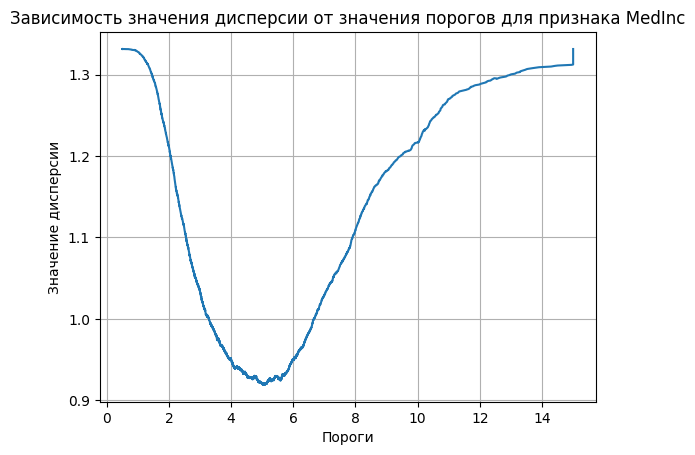

In [14]:
plt.plot(thresholds, gini)
plt.title('Зависимость значения дисперсии от значения порогов для признака MedInc')
plt.xlabel('Пороги')
plt.ylabel('Значение дисперсии')
plt.grid()
plt.show()

Найдите лучший, с вашей точки зрения, предикат первой вершины решающего дерева.

In [15]:
print(f"Наилучший педикат для первой вершины: MedInc < {threshold_best}, поскольку он наилучшим образом разделяет данные (дисперсия наименьшая)")

Наилучший педикат для первой вершины: MedInc < 5.03515, поскольку он наилучшим образом разделяет данные (дисперсия наименьшая)


**Задание 2.2 (1 балл)** Разберитесь с написанным кодом решающего дерева, заполните пропуски в коде и реализуйте недостающий метод `_predict_node()`.

Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции в разделе «Построение дерева».
- **Выбор лучшего разбиения** необходимо производить по критерию Джини.
- **Критерий останова:** все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку.
- **Ответ в листе:** наиболее часто встречающийся класс в листе.

В задаче также предлагается получить два бонуса, по баллу на каждый!

- **Реализуйте способ обрабатывать пропуски в даннх и реализуйте его, пояснив свои действия.**
- **Реализуйте метод оценки важности признаков.**

In [16]:
class DecisionTree:

    def __init__(
        self,
        feature_types: Union[List[str], np.ndarray],
        max_depth: int = None,
        min_samples_split: int = None,
        min_samples_leaf: int = None,
        task: str = "classification"
    ) -> None:

        if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))):
            raise ValueError("There is unknown feature type")

        # В этой переменной будем хранить узлы решающего дерева. Каждая вершина хранит в себе идентификатор того,
        # является ли она листовой. Листовые вершины хранят значение класса для предсказания, нелистовые - правого и
        # левого детей (поддеревья для продолжения процедуры предсказания)
        self._tree = {}

        # типы признаков (категориальные или числовые)
        self._feature_types = feature_types

        # гиперпараметры дерева
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf
        self.task = task

        # Переменная, если вы решите делать бонус
        self._feature_importances = {}


    def _fit_node(
        self,
        sub_X: np.ndarray,
        sub_y: np.ndarray,
        node: dict
    ) -> None:

        # критерий останова
        if np.all(sub_y == sub_y[0]):
            node["type"] = "terminal"
            node["class"] = sub_y[0]
            return

        feature_best, threshold_best, gini_best, split = None, None, None, None
        for feature in range(sub_X.shape[1]):
            feature_type = self._feature_types[feature]
            categories_map = {}

            # подготавливаем признак для поиска оптимального порога
            if feature_type == "real":
                feature_vector = sub_X[:, feature]
            elif feature_type == "categorical":
                # здесь могла быть реализация более сложного подхода к обработке категориального признака
                feature_vector = sub_X[:, feature]

            # ищем оптимальный порог
            _, _, threshold, gini = find_best_split(feature_vector, sub_y, self.task, feature_type)

            if gini_best is None or gini > gini_best:
                feature_best = feature
                gini_best = gini

                # split - маска на объекты, которые должны попасть в левое поддерево
                if feature_type == "real":
                    threshold_best = threshold
                    split = feature_vector <= threshold_best
                elif feature_type == "categorical":
                    # в данной реализации это просто значение категории
                    threshold_best = threshold
                    split = feature_vector == threshold_best
                else:
                    raise ValueError

        # записываем полученные сплиты в атрибуты класса
        if feature_best is None:
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0]
            return

        node["type"] = "nonterminal"

        node["feature_split"] = feature_best
        if self._feature_types[feature_best] == "real":
            node["threshold"] = threshold_best
        elif self._feature_types[feature_best] == "categorical":
            node["category_split"] = threshold_best
        else:
            raise ValueError

        node["left_child"], node["right_child"] = {}, {}
        self._fit_node(sub_X[split], sub_y[split], node["left_child"])
        self._fit_node(sub_X[np.logical_not(split)], sub_y[np.logical_not(split)], node["right_child"])

    def _predict_node(self, x: np.ndarray, node: dict) -> int:
        """
        Предсказание начинается с корневой вершины дерева и рекурсивно идёт в левое или правое поддерево в зависимости от значения
        предиката на объекте. Листовая вершина возвращает предсказание.
        :param x: np.array, элемент выборки
        :param node: dict, вершина дерева
        """
        if  node["type"] == "terminal":
          return node["class"]
        feature = node["feature_split"]
        feature_type = self._feature_types[feature]
        if feature_type == "real":
            threshold = node["threshold"]
            if x[feature] <= node["threshold"]:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])
        elif feature_type == "categorical":
            if x[feature] == node["category_split"]:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])
        else:
            raise ValueError


    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        self._fit_node(X, y, self._tree)

    def predict(self, X: np.ndarray) -> np.ndarray:
        predicted = []
        for x in X:
            predicted.append(self._predict_node(x, self._tree))

        return np.array(predicted)

**Задание 2.3 (1 балл)** Загрузите таблицу `students.csv` (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте диаграммы рассеяния "значение признака — класс" для всех пяти признаков.

In [17]:
students_data = "https://github.com/hse-ds/iad-intro-ds/raw/master/2025/homeworks/hw07_trees/students.csv"
data = pd.read_csv(students_data)
data.head(10)

,Unnamed: 0,STG,SCG,STR,LPR,PEG,UNS
0,0,0.00,0.00,0.00,0.00,0.00,0
1,1,0.08,0.08,0.10,0.24,0.90,1
2,2,0.06,0.06,0.05,0.25,0.33,0
3,3,0.10,0.10,0.15,0.65,0.30,1
4,4,0.08,0.08,0.08,0.98,0.24,0
5,5,0.09,0.15,0.40,0.10,0.66,1
6,6,0.10,0.10,0.43,0.29,0.56,1
7,7,0.15,0.02,0.34,0.40,0.01,0
8,8,0.20,0.14,0.35,0.72,0.25,0
9,9,0.00,0.00,0.50,0.20,0.85,1


In [18]:
X = data.drop(columns=['UNS', 'Unnamed: 0'])
y = data['UNS']

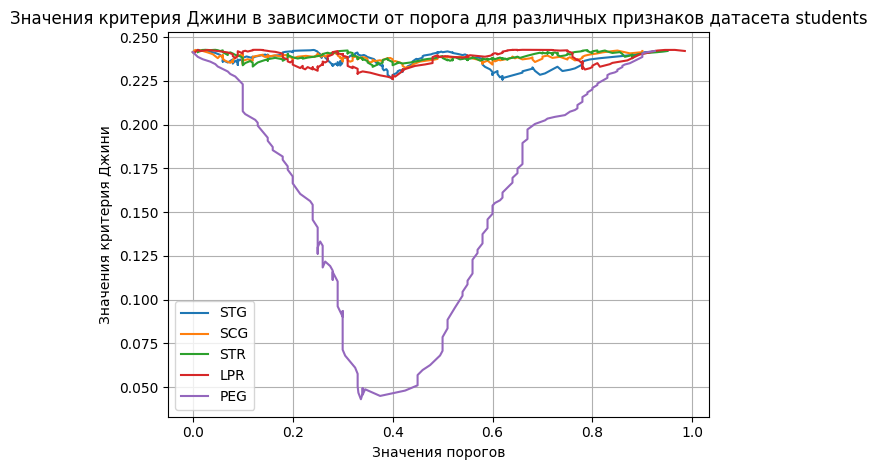

In [19]:
n = X.shape[1]
for feature in range(n):
  feature_name = X.columns[feature]
  thresholds, gini_values, threshold_best, gini_best = find_best_split(X[feature_name].values, y, task="regression", feature_type="real")
  plt.plot(thresholds, gini_values, label=f'{feature_name}')

plt.title('Значения критерия Джини в зависимости от порога для различных признаков датасета students')
plt.xlabel('Значения порогов')
plt.ylabel('Значения критерия Джини')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
print(f"Порог {threshold_best}")

Порог 0.3365


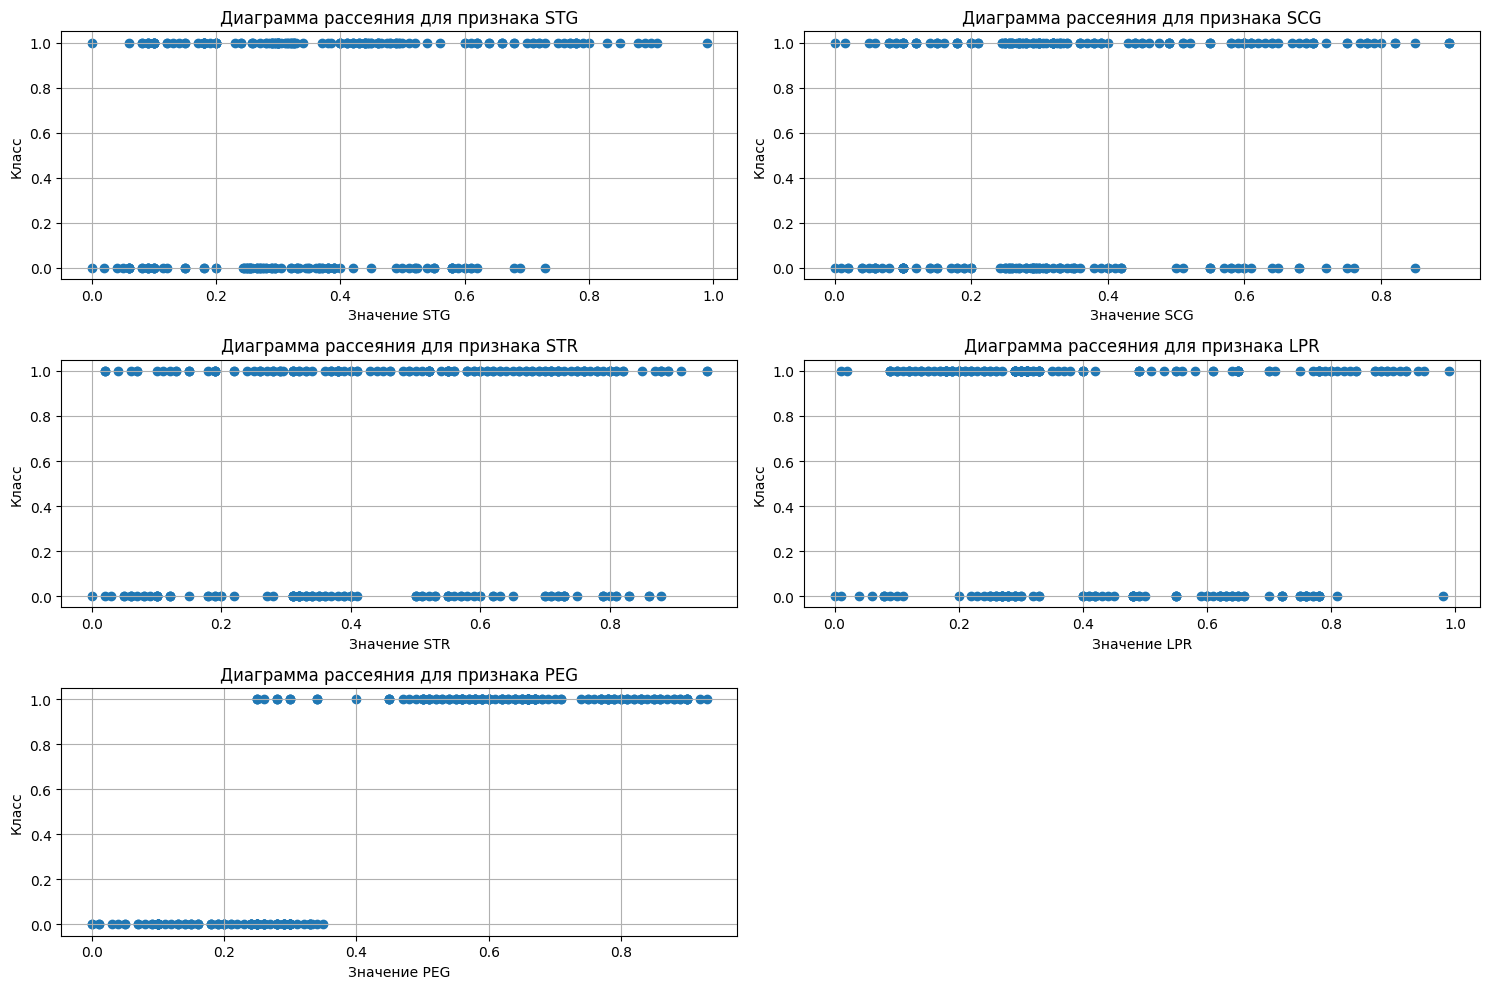

In [21]:
plt.figure(figsize=(15, 10))
for feature in range(n):
  feature_name = X.columns[feature]
  plt.subplot(3, 2, feature + 1)
  plt.scatter(X[feature_name], y)
  plt.title(f'Диаграмма рассеяния для признака {feature_name}')
  plt.xlabel(f'Значение {feature_name}')
  plt.ylabel('Класс')
  plt.grid()

plt.tight_layout()
plt.show()

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой диаграмм рассеяиния? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

**Ответ:**
Исходя из кривых значения критерия Джини, производить деление выборки на два поддерева следует по признаку PEG, поскольку для него достигается минимальное значение критерия при пороге 0.3365. Этот результат согласуется с диаграммами рассеяния. По графику для признака PEG видно, что выборка очень хорошо делится на два класса. Для остальных графиков такое не наблюдается.

Кривая для "хорошего" признака похожа на "ямку". Видно, что сначала значение критерия уменьшается и в какой-то момент достигает своего минимума, а затем снова начинает расти. Для признаков, по которым деление невозможно, кривые постоянно скачут то вверх, то вниз, а на диаграммах рассеяния невозможно провести вертикальную прямую таким образом, чтобы хорошо разделить выборку на два класса.

**Задание 2.4 (1 балл)** Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom).

1. Скачайте таблицу `agaricus-lepiota.data` (из [Data Folder](https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/)),
2. Считайте таблицу при помощи `pandas`,
3. Примените к каждому столбцу `LabelEncoder` (из `sklearn`), чтобы преобразовать строковые имена категорий в натуральные числа.

Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

In [22]:
data = pd.read_csv('agaricus-lepiota.data', header=None)
data

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [23]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
data = data.apply(label_encoder.fit_transform)
data

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,0,3,2,4,0,5,0,0,0,11,...,2,5,5,0,1,1,4,0,1,2
8120,0,5,2,4,0,5,0,0,0,11,...,2,5,5,0,0,1,4,0,4,2
8121,0,2,2,4,0,5,0,0,0,5,...,2,5,5,0,1,1,4,0,1,2
8122,1,3,3,4,0,8,1,0,1,0,...,1,7,7,0,2,1,0,7,4,2


In [24]:
X = data.drop(columns=[0])
y = data[0]

In [25]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score
import sys
sys.setrecursionlimit(10000)
dt = DecisionTree(feature_types=["real"] * x_train.shape[1])
dt.fit(x_train.values, y_train.values)

y_pred = dt.predict(x_test.values)
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность: {accuracy:.2f}")

KeyboardInterrupt: 

## Часть 3: Бэггинг и случайный лес (4 балла)

В данной части мы будем работать [с задачей предсказания диабета у пациента](https://www.kaggle.com/uciml/pima-indians-diabetes-database/data). Посмотрим на работу бэггинга над решающими деревьями и случайного леса, сравним их работу.

In [26]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [27]:
diabetes_data = "https://github.com/hse-ds/iad-intro-ds/raw/master/2025/homeworks/hw07_trees/diabetes.csv"
data = pd.read_csv(diabetes_data)
print(f"Dataset shape: {data.shape}")
data.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Посмотрим на распределение целевой переменной

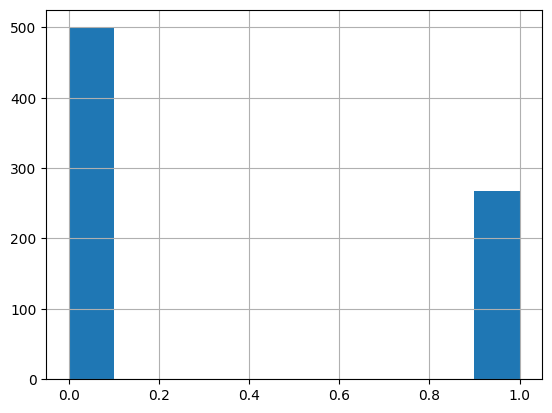

In [28]:
data['Outcome'].hist()
plt.show()

**Задание 3.1 (0.5 балла)** Разделите данные на признаки и целевую переменную. Разбейте датасет на обучающую и тестовую части в отношении 7:3. Затем разделите обучающую выборку на обучающую-обучающую и обучающую-валидационную в соотношении 7:3 (то есть в итоге должно получиться три выборки: обучающая-обучающая (0.49 от исходного датасета), обучающая-валидационная (0.21 от исходного датасета) и тестовая (0.3 от исходного датасета).

In [29]:
X = data.drop(columns='Outcome')
y = data['Outcome']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

x_train_train, x_train_val, y_train_train, y_train_val = train_test_split(x_train, y_train, test_size=0.3, random_state=42)

**Задание 3.2 (1 балл)** На обучающей-валидационной выборке подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_leaf` для `DecisionTreeClassifier`. Для этого:
1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений обучите дерево на обучающей-обучающей выборке и определите качество на обучающей-валидационной выборке. В качестве критерия будем использовать `f1-меру`.
3. Выберите ту пару значений, которая даёт наилучшее качество на обучающей-валидационной выборке.


Обучите решающее дерево с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по метрикам `accuracy`, `precision` и `recall`, `auc_roc`.

In [30]:
from sklearn.metrics import f1_score
max_depths = [None, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15]
min_samples_leaves = [1, 2, 3, 5, 6, 7, 8, 10]

maxF1 = 0
best_depth = None
best_samples_leaf = None

for max_depth in max_depths:
    for min_samples_leaf in min_samples_leaves:
        tree_clf = DecisionTreeClassifier(max_depth = max_depth, min_samples_leaf = min_samples_leaf, random_state=42)
        tree_clf.fit(x_train_train, y_train_train)
        y_train_val_pred = tree_clf.predict(x_train_val)
        f1 = f1_score(y_train_val, y_train_val_pred)
        if f1 > maxF1:
            maxF1 = f1
            best_depth = max_depth
            best_samples_leaf = min_samples_leaf

print(f"Оптимальные значения гиперпараметров: max_depth={best_depth} и min_samples_leaf={best_samples_leaf}")
print(f"Значение f1-меры для этих параметров: {maxF1}")

Оптимальные значения гиперпараметров: max_depth=7 и min_samples_leaf=7
Значение f1-меры для этих параметров: 0.7142857142857143


In [31]:
tree_clf = DecisionTreeClassifier(max_depth = 7, min_samples_leaf = 7, random_state=42)
tree_clf.fit(x_train, y_train)
y_test_pred = tree_clf.predict(x_test)

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
roc_auc = roc_auc_score(y_test, tree_clf.predict_proba(x_test)[:, 1])

print(f"Значение accuracy: {accuracy}")
print(f"Значение precision: {precision}")
print(f"Значение recall: {recall}")
print(f"Площадь AUC-ROC: {roc_auc}")

Значение accuracy: 0.696969696969697
Значение precision: 0.5555555555555556
Значение recall: 0.625
Площадь AUC-ROC: 0.7517384105960265


**Задание 3.3 (0.5 балла)** Обучите [`BaggingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html) на 50 деревьях на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по тем же метрикам.

In [33]:
estimator = DecisionTreeClassifier(random_state=35)
bag_clf = BaggingClassifier(estimator=estimator, n_estimators=50, random_state=35)
bag_clf.fit(x_train, y_train)
y_test_pred = bag_clf.predict(x_test)

In [34]:
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
roc_auc = roc_auc_score(y_test, bag_clf.predict_proba(x_test)[:, 1])

print(f"Значение accuracy: {accuracy}")
print(f"Значение precision: {precision}")
print(f"Значение recall: {recall}")
print(f"Площадь AUC-ROC: {roc_auc}")

Значение accuracy: 0.7359307359307359
Значение precision: 0.6091954022988506
Значение recall: 0.6625
Площадь AUC-ROC: 0.7967715231788081


**Задание 3.4 (1 балл)** Выполните кросс-валидацию на полной обучающей выборке и подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_split` для `Random Forest` с 50 деревьями. Для этого:

1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений проведите кросс-валидацию на полной обучающей выборке. Количество разбиений выберите на ваш вкус. В качестве критерия будем использовать `f1-меру`. Усредните значение критерия по всем прогонам кросс-валидации.
3. Выберите ту пару значений, которая даёт наилучшее среднее качество.

Обучите случайный лес с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации по тем же метрикам. Какая из трёх построенных моделей показала себя лучше?

In [35]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score

params_grid = {
    'max_depth': [None, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15],
    'min_samples_split': [2 , 5, 6, 7, 8, 10]
}

rf = RandomForestClassifier(n_estimators=50, random_state=32)
grid_search = GridSearchCV(rf, params_grid, cv=5, scoring='f1', verbose=1, n_jobs=-1)
grid_search.fit(X, y)
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f"Оптимальные значения гиперпараметров: max_depth={best_params['max_depth']} и min_samples_split={best_params['min_samples_split']}")
print(f"Среднее значение f1-меры для этих параметров: {best_score}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Оптимальные значения гиперпараметров: max_depth=10 и min_samples_split=10
Среднее значение f1-меры для этих параметров: 0.6524653781823069


In [36]:
rf = RandomForestClassifier(max_depth=10, min_samples_split=10, n_estimators=50, random_state=42)
rf.fit(x_train, y_train)
y_test_pred = rf.predict(x_test)

In [37]:
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
roc_auc = roc_auc_score(y_test, rf.predict_proba(x_test)[:, 1])

print(f"Значение accuracy: {accuracy}")
print(f"Значение precision: {precision}")
print(f"Значение recall: {recall}")
print(f"Площадь AUC-ROC: {roc_auc}")

Значение accuracy: 0.7489177489177489
Значение precision: 0.6341463414634146
Значение recall: 0.65
Площадь AUC-ROC: 0.8171357615894039


In [38]:
data = {
    'Модель': ['Решающее дерево', 'Бэггинг', 'Случайный лес'],
    'Accuracy': [0.697, 0.736, 0.749],
    'Precision': [0.556, 0.610, 0.634],
    'Recall': [0.625, 0.663, 0.65],
    'AUC-ROC': [0.752, 0.797, 0.817]
}

df = pd.DataFrame(data)
display(df)

,Модель,Accuracy,Precision,Recall,AUC-ROC
0,Решающее дерево,0.697,0.556,0.625,0.752
1,Бэггинг,0.736,0.610,0.663,0.797
2,Случайный лес,0.749,0.634,0.650,0.817


**Ответ:** исходя из полученных метрик, можно сдлеать вывод, что лучшей моделью является случайный лес. Она имеет наибольшую долю верных ответов (accuracy = 0.749), высокую точность предсказания положительного класса (precision = 0.634) и самую большую площадь под кривой ROC (AUC-ROC = 0.817).

**Задание 3.5 (0.5 балла)** Постройте график зависимости AUC ROC на тестовой выборке от числа деревьев (`n_estimators`) для случайного леса, обучаемого на **полной обучающей** выборке. Какие выводы можно сделать?

In [39]:
from sklearn.datasets import make_classification

n_estimators_range = np.arange(10, 800, 20)
auc_scores = dict()

for n_estimators in n_estimators_range:
    rf = RandomForestClassifier(n_estimators=n_estimators, random_state=35)
    rf.fit(x_train, y_train)
    y_probs = rf.predict_proba(x_test)[:, 1]
    auc = roc_auc_score(y_test, y_probs)
    auc_scores[n_estimators] = auc

<ipython-input-40-1533109088>:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


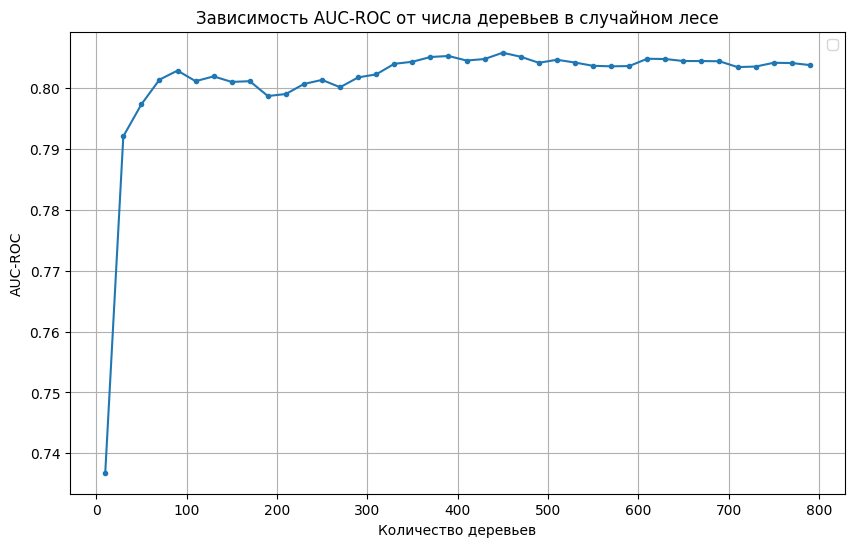

In [40]:
n_estimators_list = list(auc_scores.keys())
auc_scores_list = list(auc_scores.values())

plt.figure(figsize=(10, 6))
plt.plot(n_estimators_list, auc_scores_list, marker='.')
plt.title('Зависимость AUC-ROC от числа деревьев в случайном лесе')
plt.xlabel('Количество деревьев')
plt.ylabel('AUC-ROC')
plt.grid()
plt.legend()
plt.show()

**Ответ:** по графику видно, что с увеличением числа деревьев значение площади AUC-ROOC стабилизируется и остается примерно на одном уровне.Это показывает, что случайный лес не переобучается при увеличении числа деревьев.

**Задание 3.6 (0.5 балла)** Для лучшей модели случайного леса из **Задания 3.4** посчитайте важность признаков и постройте bar plot. Какой признак оказался самым важным для определения диабета?

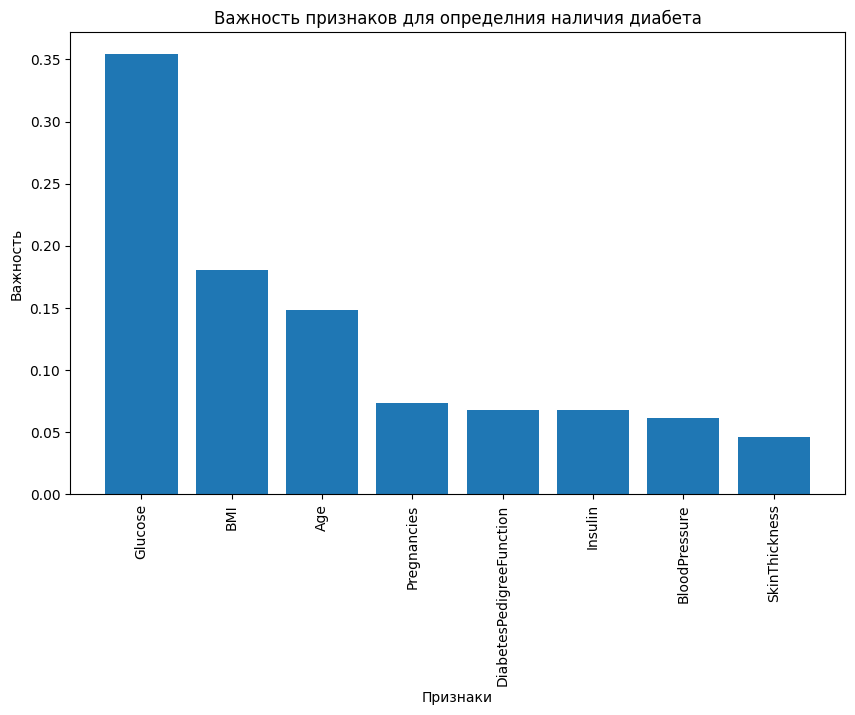

In [41]:
model = RandomForestClassifier(n_estimators=50,
                               max_depth=10,
                               min_samples_leaf=6,
                               random_state=42)
model.fit(x_train, y_train)
importances = model.feature_importances_
feature_names = x_test.columns
indices = np.argsort(importances)[::-1]
size = X.shape[1]
plt.figure(figsize=(10, 6))
plt.title('Важность признаков для определния наличия диабета')
plt.bar(range(size), importances[indices], align='center')
plt.xticks(range(size), np.array(feature_names)[indices], rotation=90)
plt.xlabel('Признаки')
plt.ylabel('Важность')
plt.show()

**Ответ:** самым важным при определении диабета является признак "Glucose" - уровень глюкозы в крови. Это действительно является показателем к диабету: если уровень сахара в крови высокий, то и вероятность диабета тоже высокая.